# exp-gs-002-02 — H-AS + DOMAIN-04A 정확 변이 core

## 목적

홍주님 H-AS backbone(G+B+V+T+R+A+S)에 DOMAIN-04A의 **Logistic 전용 정확 변이 4개만** 추가한다. gene pair와 group-count는 아직 넣지 않아, 정확 변이 블록의 독립 효과를 먼저 확인한다.

- Backbone: H-AS
- 추가 피처: `BRAF V600E`, `IDH1 R132H`, `PIK3CA H1047R`, `PIK3CA E545K`
- 고정: Logistic lbfgs, C=0.07, max_iter=2000, class_weight=balanced, StratifiedKFold-5
- seeds: 42 / 2024 / 777
- 평가: OOF Macro F1
- 누수: exact feature는 행 문자열에서 직접 생성하며, test를 fit·통계·피처선택에 사용하지 않는다.
- NaN: test의 NaN 237개는 mutation/event로 처리하지 않는다.

> H-AS는 홍주님이 이미 3-seed로 검증했다. 이 노트북은 H-AS를 재실행하지 않고, 정확 변이 추가 후보만 새로 실행한다.

## 비교 기준과 가설

팀의 기존 H-AS 결과는 OOF Macro F1 **0.433329 ± 0.002785**이며 수렴 경고가 있었다. 이 값은 참고 기준이다. 이번 실행기의 결과가 생성되면 동일한 leakage/NaN 감사와 max_iter=2000 조건에서 H-AS + exact의 3-seed 결과를 기록한다.

정확 변이는 gene-level binary보다 암종 특이적 hotspot 신호를 더 세밀하게 전달할 수 있다. 다만 원래 DOMAIN-04A의 단일 제거 분석에서 Logistic에는 exact `PIK3CA H1047R`, `IDH1 R132H`, `BRAF V600E`가 유효했고, 무분별한 조합은 피한다.

In [5]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda value: f'{value:.6f}')


def find_eda_dir() -> Path:
    start = Path.cwd()
    for candidate in (start, *start.parents):
        direct = candidate / 'common' / 'exp-gs-002-memory-safe.py'
        from_project_root = candidate / 'experiments' / 'gs' / 'notebooks' / 'eda_pre_002' / 'common' / 'exp-gs-002-memory-safe.py'
        if direct.exists():
            return candidate
        if from_project_root.exists():
            return from_project_root.parent.parent
    raise FileNotFoundError('프로젝트 루트 또는 eda_pre_002에서 실행하세요.')


EDA_DIR = find_eda_dir()
ROOT = EDA_DIR.parents[3]
RUNNER = EDA_DIR / 'common' / 'exp-gs-002-memory-safe.py'
RESULT_DIR = EDA_DIR / 'result'

RUN_ID = 'exp-gs-002-02'
CANDIDATE = 'H-AS-LR-exact'
MODEL = 'logistic'
SEEDS = (42, 2024, 777)
REFERENCE_H_AS_MEAN = 0.433329
REFERENCE_H_AS_STD = 0.002785

assert RUNNER.exists(), RUNNER
assert RESULT_DIR.exists(), RESULT_DIR

{
    'runner': RUNNER,
    'result_dir': RESULT_DIR,
    'candidate': CANDIDATE,
    'seeds': SEEDS,
    'fixed_model': 'lbfgs / C=0.07 / max_iter=2000 / class_weight=balanced',
    'reference_h_as_oof_macro_f1': f'{REFERENCE_H_AS_MEAN:.6f} ± {REFERENCE_H_AS_STD:.6f}',
}

{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/eda_pre_002/common/exp-gs-002-memory-safe.py'),
 'result_dir': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/eda_pre_002/result'),
 'candidate': 'H-AS-LR-exact',
 'seeds': (42, 2024, 777),
 'fixed_model': 'lbfgs / C=0.07 / max_iter=2000 / class_weight=balanced',
 'reference_h_as_oof_macro_f1': '0.433329 ± 0.002785'}

## 실행

기본값은 `False`다. True로 변경 후 실행하면 seed별 tqdm과 실행기 내부 fold tqdm이 표시된다. 완료된 seed 결과는 result/에 보존된다.

In [6]:
RUN_EXPERIMENT = True  # 실제 실행 시에만 True로 변경

if RUN_EXPERIMENT:
    for seed in tqdm(SEEDS, desc=f'{RUN_ID} | {CANDIDATE} | 3-seed', unit='seed'):
        command = [
            sys.executable,
            str(RUNNER),
            '--run-id', RUN_ID,
            '--candidate', CANDIDATE,
            '--model', MODEL,
            '--seed', str(seed),
        ]
        completed = subprocess.run(command, cwd=ROOT, check=False)
        if completed.returncode != 0:
            raise RuntimeError(f'seed={seed} 실행 실패 (returncode={completed.returncode})')
else:
    print('미실행 상태입니다. 실행하려면 RUN_EXPERIMENT = True로 변경하세요.')

exp-gs-002-02 | H-AS-LR-exact | 3-seed:   0%|          | 0/3 [00:00<?, ?seed/s]

row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 395.24it/s]
H-AS-LR-exact | logistic | seed 42: 100%|██████████| 5/5 [04:48<00:00, 57.71s/it]


{
  "experiment_id": "H-AS-LR-exact",
  "model": "logistic",
  "seed": 42,
  "oof_macro_f1": 0.4312924774297094,
  "oof_accuracy": 0.42009353330108046,
  "fold_macro_f1_mean": 0.4304266365637842,
  "fold_macro_f1_std": 0.010892601328795146,
  "feature_count_mean": 8217.2,
  "runtime_seconds": 288.6251745829977,
  "convergence_warning_count": 5,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 395.65it/s].25s/seed]
H-AS-LR-exact | logistic | seed 2024: 100%|██████████| 5/5 [04:51<00:00, 58.25s/it]


{
  "experiment_id": "H-AS-LR-exact",
  "model": "logistic",
  "seed": 2024,
  "oof_macro_f1": 0.4361044545065911,
  "oof_accuracy": 0.4228350266086115,
  "fold_macro_f1_mean": 0.4362236019964647,
  "fold_macro_f1_std": 0.008394835265655192,
  "feature_count_mean": 8217.0,
  "runtime_seconds": 291.34218408299785,
  "convergence_warning_count": 5,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


row-local mutation cache: 100%|██████████| 4384/4384 [00:10<00:00, 399.35it/s].84s/seed]
H-AS-LR-exact | logistic | seed 777: 100%|██████████| 5/5 [04:45<00:00, 57.06s/it]


{
  "experiment_id": "H-AS-LR-exact",
  "model": "logistic",
  "seed": 777,
  "oof_macro_f1": 0.4330388473133259,
  "oof_accuracy": 0.42364134816965004,
  "fold_macro_f1_mean": 0.4323506257589299,
  "fold_macro_f1_std": 0.011392003181874052,
  "feature_count_mean": 8212.4,
  "runtime_seconds": 285.3899151250007,
  "convergence_warning_count": 5,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


exp-gs-002-02 | H-AS-LR-exact | 3-seed: 100%|██████████| 3/3 [15:41<00:00, 313.97s/seed]


## 3-seed 요약

세 seed가 모두 있을 때만 평균과 표준편차를 계산한다. convergence warning, leakage_check, nan_as_mutation_count를 함께 저장한다.

In [7]:
def oof_path(seed: int) -> Path:
    return RESULT_DIR / f'{RUN_ID}_{CANDIDATE}_{MODEL}_seed{seed}_oof.csv'


def class_f1_path(seed: int) -> Path:
    return RESULT_DIR / f'{RUN_ID}_{CANDIDATE}_{MODEL}_seed{seed}_class_f1.csv'


missing = [oof_path(seed) for seed in SEEDS if not oof_path(seed).exists()]

if missing:
    print('아직 필요한 OOF 결과 파일이 없습니다:')
    for path in missing:
        print(' -', path.name)
else:
    runs = pd.concat([pd.read_csv(oof_path(seed)) for seed in SEEDS], ignore_index=True)
    summary = (
        runs.groupby(['experiment_id', 'model'], as_index=False)
        .agg(
            seed_count=('seed', 'nunique'),
            oof_macro_f1_mean=('oof_macro_f1', 'mean'),
            oof_macro_f1_std=('oof_macro_f1', 'std'),
            oof_accuracy_mean=('oof_accuracy', 'mean'),
            feature_count_mean=('feature_count_mean', 'mean'),
            runtime_seconds_mean=('runtime_seconds', 'mean'),
            convergence_warning_count=('convergence_warning_count', 'sum'),
            leakage_check=('leakage_check', 'all'),
            nan_as_mutation_count=('nan_as_mutation_count', 'max'),
        )
    )
    summary['delta_vs_team_H_AS_reference'] = summary['oof_macro_f1_mean'] - REFERENCE_H_AS_MEAN
    summary_path = RESULT_DIR / f'{RUN_ID}_3seed_summary.csv'
    summary.to_csv(summary_path, index=False)
    display(runs.sort_values('seed'))
    display(summary)
    print(f'저장 완료: {summary_path.name}')

,experiment_id,model,seed,oof_macro_f1,oof_accuracy,fold_macro_f1_mean,fold_macro_f1_std,feature_count_mean,runtime_seconds,convergence_warning_count,leakage_check,nan_as_mutation_count
0,H-AS-LR-exact,logistic,42,0.431292,0.420094,0.430427,0.010893,8217.200000,288.625175,5,True,0
2,H-AS-LR-exact,logistic,777,0.433039,0.423641,0.432351,0.011392,8212.400000,285.389915,5,True,0
1,H-AS-LR-exact,logistic,2024,0.436104,0.422835,0.436224,0.008395,8217.000000,291.342184,5,True,0


,experiment_id,model,seed_count,oof_macro_f1_mean,oof_macro_f1_std,oof_accuracy_mean,feature_count_mean,runtime_seconds_mean,convergence_warning_count,leakage_check,nan_as_mutation_count,delta_vs_team_H_AS_reference
0,H-AS-LR-exact,logistic,3,0.433479,0.002436,0.422190,8215.533333,288.452425,15,True,0,0.000150


저장 완료: exp-gs-002-02_3seed_summary.csv


## 클래스별 F1 및 시각화

클래스별 변화는 보조 지표다. 최종 후보 판단에는 OOF 평균·표준편차와 warning, leakage/NaN 점검을 함께 사용한다.

,class,class_f1_mean,class_f1_std,support
0,SKCM,0.866205,0.003103,276.000000
1,ACC,0.772511,0.021969,72.000000
2,COAD,0.730908,0.001877,223.000000
3,THCA,0.683422,0.006340,324.000000
4,UCEC,0.550189,0.008596,198.000000
5,TGCT,0.544605,0.020672,124.000000
6,LUSC,0.528418,0.014566,178.000000
7,STES,0.500417,0.007757,379.000000
8,BRCA,0.483705,0.006051,786.000000
9,LGG,0.471177,0.010561,229.000000


,class,class_f1_mean,class_f1_std,support
16,DLBC,0.361659,0.043358,38.000000
17,PRAD,0.338028,0.005212,266.000000
18,BLCA,0.336292,0.005450,104.000000
19,HNSC,0.336100,0.012835,223.000000
20,GBMLGG,0.329722,0.012671,461.000000
21,PCPG,0.280071,0.011688,147.000000
22,THYM,0.235628,0.017778,98.000000
23,KIPAN,0.194347,0.006805,515.000000
24,SARC,0.191481,0.007936,198.000000
25,KIRC,0.180005,0.015034,334.000000


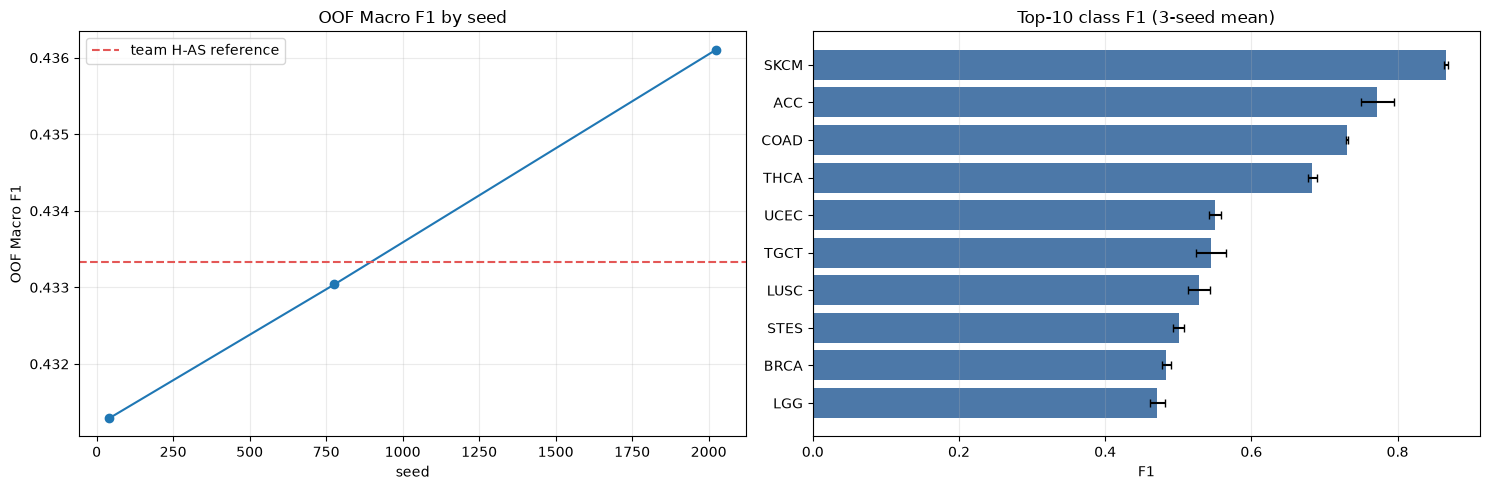

저장 완료: exp-gs-002-02_class_f1_3seed_summary.csv


In [8]:
missing_class = [class_f1_path(seed) for seed in SEEDS if not class_f1_path(seed).exists()]

if missing_class:
    print('아직 필요한 class F1 결과 파일이 없습니다:')
    for path in missing_class:
        print(' -', path.name)
else:
    class_runs = pd.concat([pd.read_csv(class_f1_path(seed)) for seed in SEEDS], ignore_index=True)
    class_summary = (
        class_runs.groupby('class', as_index=False)
        .agg(
            class_f1_mean=('f1-score', 'mean'),
            class_f1_std=('f1-score', 'std'),
            support=('support', 'mean'),
        )
        .sort_values('class_f1_mean', ascending=False)
        .reset_index(drop=True)
    )
    class_summary_path = RESULT_DIR / f'{RUN_ID}_class_f1_3seed_summary.csv'
    class_summary.to_csv(class_summary_path, index=False)

    display(class_summary.head(10))
    display(class_summary.tail(10))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].plot(runs.sort_values('seed')['seed'], runs.sort_values('seed')['oof_macro_f1'], marker='o')
    axes[0].axhline(REFERENCE_H_AS_MEAN, color='#E45756', linestyle='--', label='team H-AS reference')
    axes[0].set_title('OOF Macro F1 by seed')
    axes[0].set_xlabel('seed')
    axes[0].set_ylabel('OOF Macro F1')
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    top = class_summary.head(10).sort_values('class_f1_mean')
    axes[1].barh(top['class'], top['class_f1_mean'], xerr=top['class_f1_std'], capsize=3, color='#4C78A8')
    axes[1].set_title('Top-10 class F1 (3-seed mean)')
    axes[1].set_xlabel('F1')
    axes[1].grid(axis='x', alpha=0.25)

    plt.tight_layout()
    plt.show()
    print(f'저장 완료: {class_summary_path.name}')

## 판정 및 다음 단계

- 통과: OOF Macro F1이 H-AS 참고 기준보다 일관되게 개선되고, std·수렴 경고가 허용 가능한 수준이며 leakage_check=True / nan_as_mutation_count=0
- 보류: 개선폭이 변동성보다 작거나 warning이 크게 늘어나는 경우
- 다음: 통과할 때만 `IDH1-TP53`, `IDH1-ATRX`, `APC-TP53` gene-pair를 별도 실험(-03)으로 추가한다. exact+pair 전체 조합은 pair 단독 효과가 확인된 뒤 진행한다.